<a href="https://colab.research.google.com/github/202204417/25-2-DIP-202204417/blob/main/HW_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.ndimage as nd
from PIL import Image

In [1]:
from google.colab import drive
drive.mount('/content/drive')
imgpath = '/content/drive/MyDrive/DIP_image'

Mounted at /content/drive


## Erosion

In [ ]:
I = np.array([[0,0,1,1,0,1],[1,1,1,1,1,0],[0,1,1,1,1,1]])
print('Object')
print(I)
se = np.array([[0,1,0],[1,1,1],[0,1,0]])
print('SE')
print(se)
R = nd.binary_erosion(I,se).astype(np.int8)
print('Eroded Result')
print(R)

Object
[[0 0 1 1 0 1]
 [1 1 1 1 1 0]
 [0 1 1 1 1 1]]
SE
[[0 1 0]
 [1 1 1]
 [0 1 0]]
Eroded Result
[[0 0 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 0 0]]


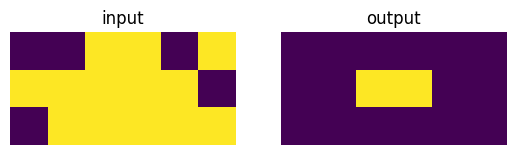

In [ ]:
plt.subplot(121)
plt.imshow(I)
plt.axis('off')
plt.title('input')
plt.subplot(122)
plt.imshow(R)
plt.axis('off')
plt.title('output')
plt.show()

## Dilation

In [ ]:
I = np.array([[0,0,1,1,0,0],[0,0,1,1,1,0],[0,0,0,1,0,0],[0,0,1,1,1,0],[0,0,0,0,0,0]])
print('Object')
print(I)
se = np.array([[0,1,0],[1,1,1],[0,1,0]])
print('SE')
print(se)
R = nd.binary_dilation(I,se).astype(np.int8)
print('Dilated Result')
print(R)

Object
[[0 0 1 1 0 0]
 [0 0 1 1 1 0]
 [0 0 0 1 0 0]
 [0 0 1 1 1 0]
 [0 0 0 0 0 0]]
SE
[[0 1 0]
 [1 1 1]
 [0 1 0]]
Dilated Result
[[0 1 1 1 1 0]
 [0 1 1 1 1 1]
 [0 0 1 1 1 0]
 [0 1 1 1 1 1]
 [0 0 1 1 1 0]]


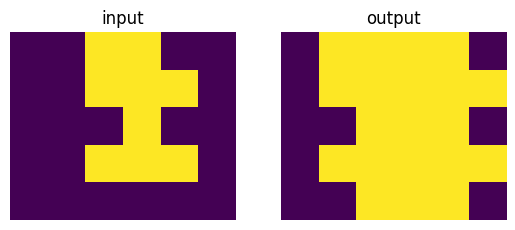

In [ ]:
plt.subplot(121)
plt.imshow(I)
plt.axis('off')
plt.title('input')
plt.subplot(122)
plt.imshow(R)
plt.axis('off')
plt.title('output')
plt.show()

## Erosion

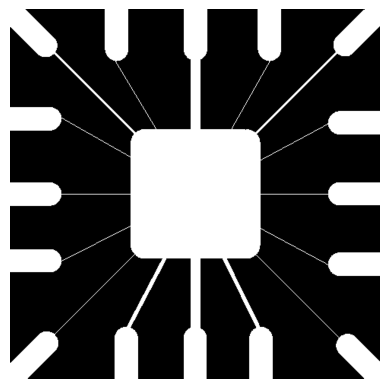

In [ ]:
I = Image.open(imgpath+'/circuitmask.tif')
f = np.array(I)>0
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

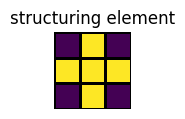

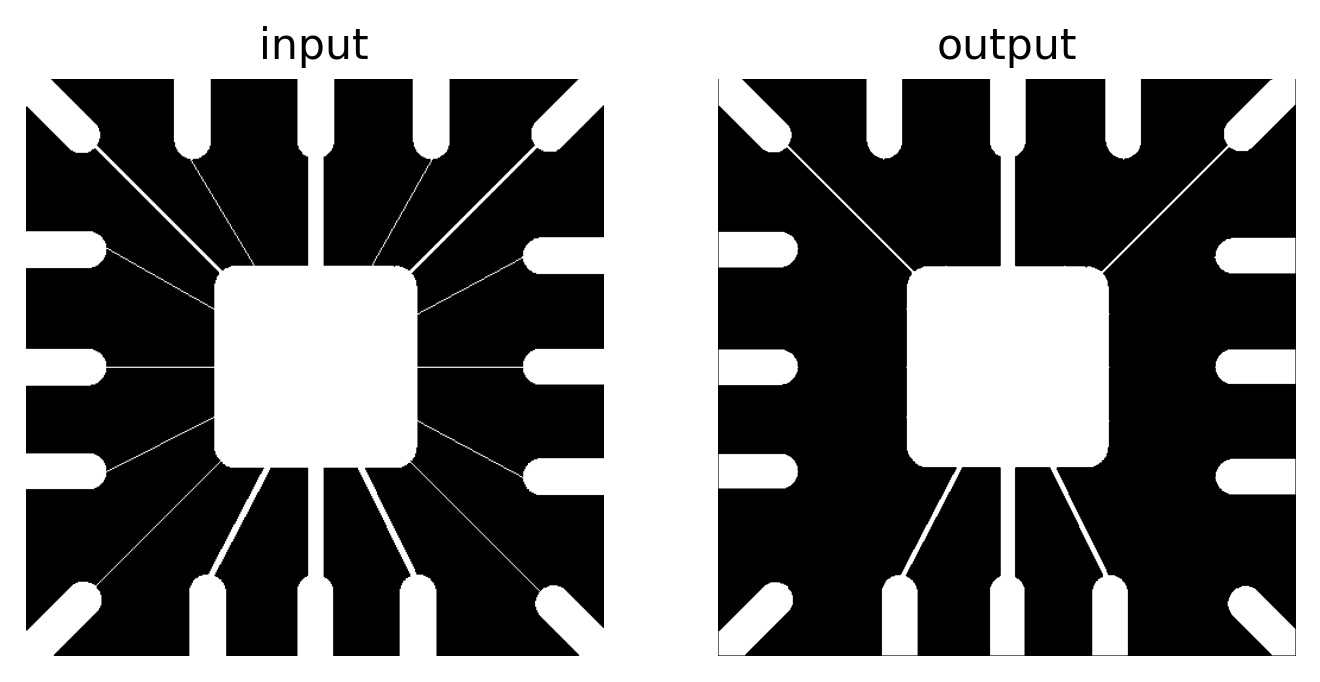

In [ ]:
se = np.array([[0,1,0],[1,1,1],[0,1,0]])
plt.figure(figsize=(1,1))
plt.pcolormesh(se, edgecolors='k', linewidth=2)
plt.title('structuring element')
plt.axis('off')
plt.show()

g = nd.binary_erosion(f,se)

plt.figure(dpi=256)
plt.subplot(121)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.title('input')
plt.subplot(122)
plt.imshow(g,cmap='gray')
plt.axis('off')
plt.title('output')
plt.show()

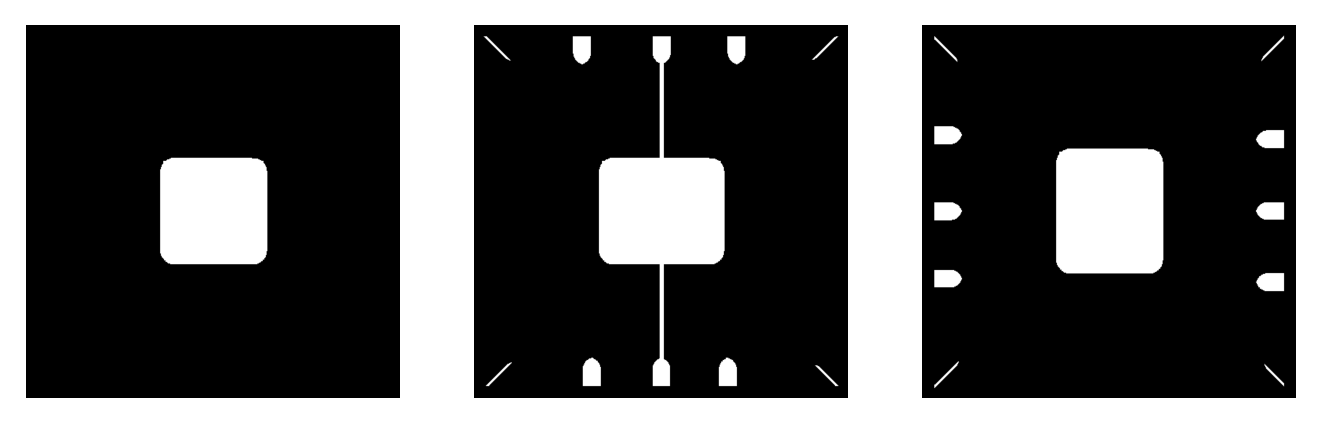

In [ ]:
se1 = np.ones((64,64))
se2 = np.ones((64,16))
se3 = np.ones((16,64))

plt.figure(dpi=256)

g1 = nd.binary_erosion(f,se1)
plt.subplot(131)
plt.imshow(g1,cmap='gray')
plt.axis('off')

g2 = nd.binary_erosion(f,se2)
plt.subplot(132)
plt.imshow(g2,cmap='gray')
plt.axis('off')

g3 = nd.binary_erosion(f,se3)
plt.subplot(133)
plt.imshow(g3,cmap='gray')
plt.axis('off')

plt.show()

## Dilation

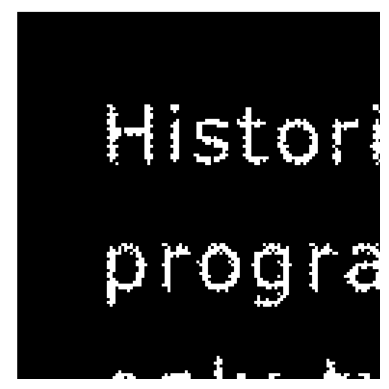

In [ ]:
I = Image.open(imgpath+'/text-broken.tif')
f = np.array(I)>0
f = f[:256,:256]
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

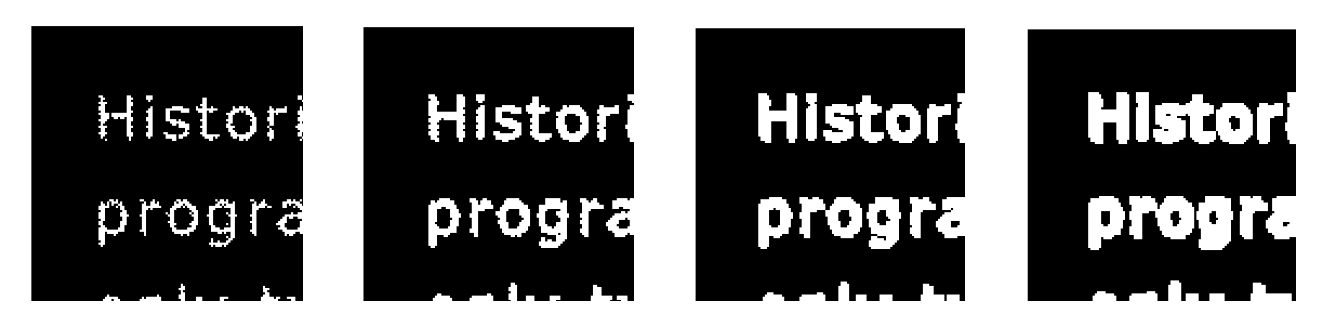

In [ ]:
se1 = np.ones((3,3))
se2 = np.ones((5,5))
se3 = np.ones((7,7))

plt.figure(dpi=256)
plt.subplot(141)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.subplot(142)
g1 = nd.binary_dilation(f,se1)
plt.imshow(g1,cmap='gray')
plt.axis('off')
plt.subplot(143)
g2 = nd.binary_dilation(f,se2)
plt.imshow(g2,cmap='gray')
plt.axis('off')
plt.subplot(144)
g3 = nd.binary_dilation(f,se3)
plt.imshow(g3,cmap='gray')
plt.axis('off')
plt.show()


## Opening and Closing

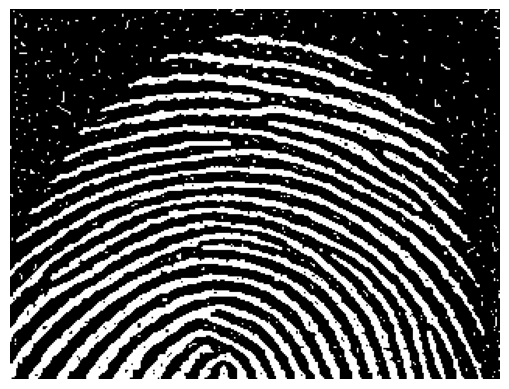

In [ ]:
I = Image.open(imgpath+'/fingerprint-noisy.tif').convert('L')
f = np.array(I)>0
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

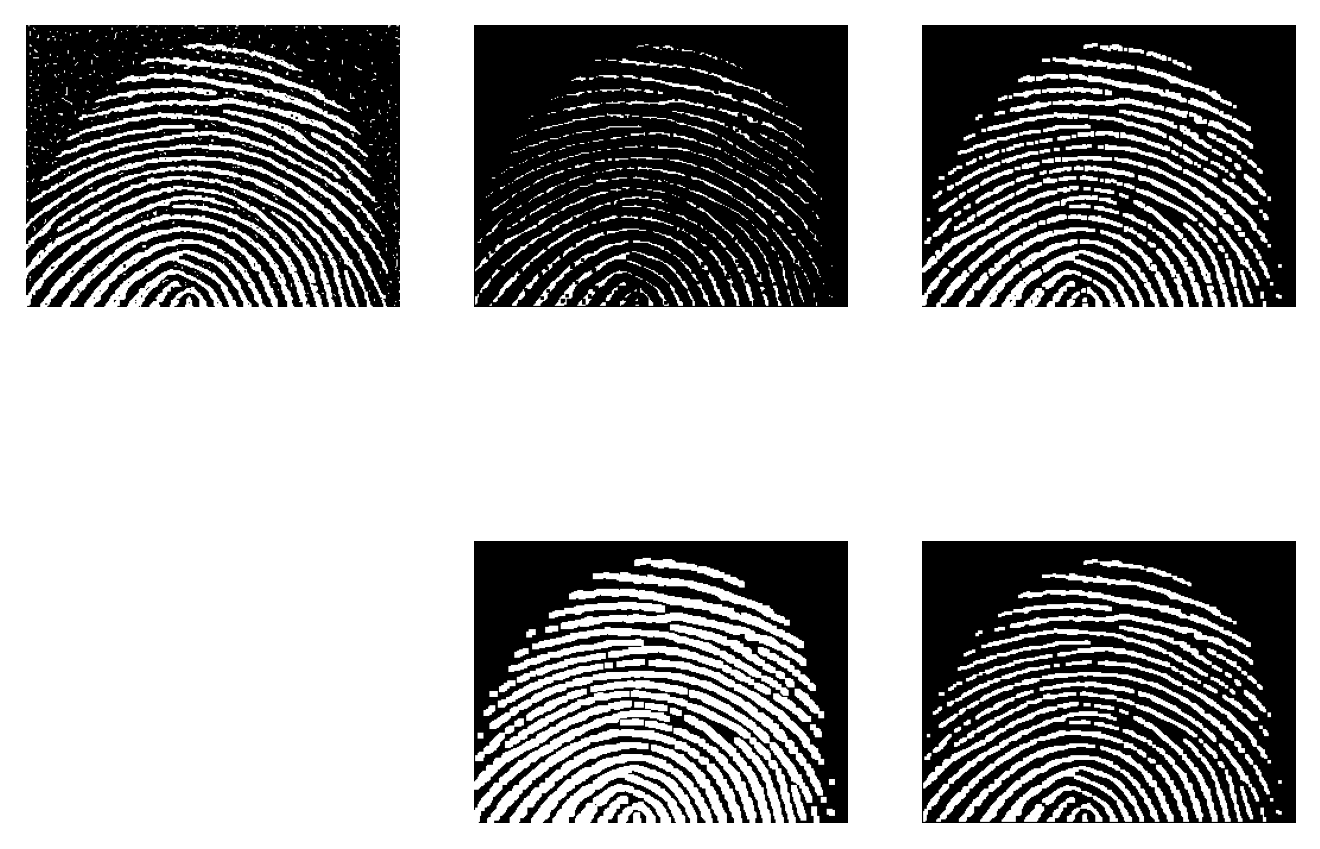

In [ ]:
se = np.ones((3,3))
g1 = nd.binary_erosion(f,se)
g2 = nd.binary_dilation(g1,se)
g3 = nd.binary_dilation(g2,se)
g4 = nd.binary_erosion(g3,se)

plt.figure(dpi=256)
plt.subplot(231)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.subplot(232)
plt.imshow(g1,cmap='gray')
plt.axis('off')
plt.subplot(233)
plt.imshow(g2,cmap='gray')
plt.axis('off')
plt.subplot(235)
plt.imshow(g3,cmap='gray')
plt.axis('off')
plt.subplot(236)
plt.imshow(g4,cmap='gray')
plt.axis('off')
plt.show()



## Boundary Extraction

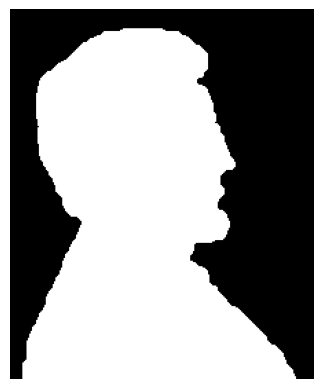

In [ ]:
I = Image.open(imgpath+'/lincoln.tif')#.convert('L')
f = np.array(I)>0
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

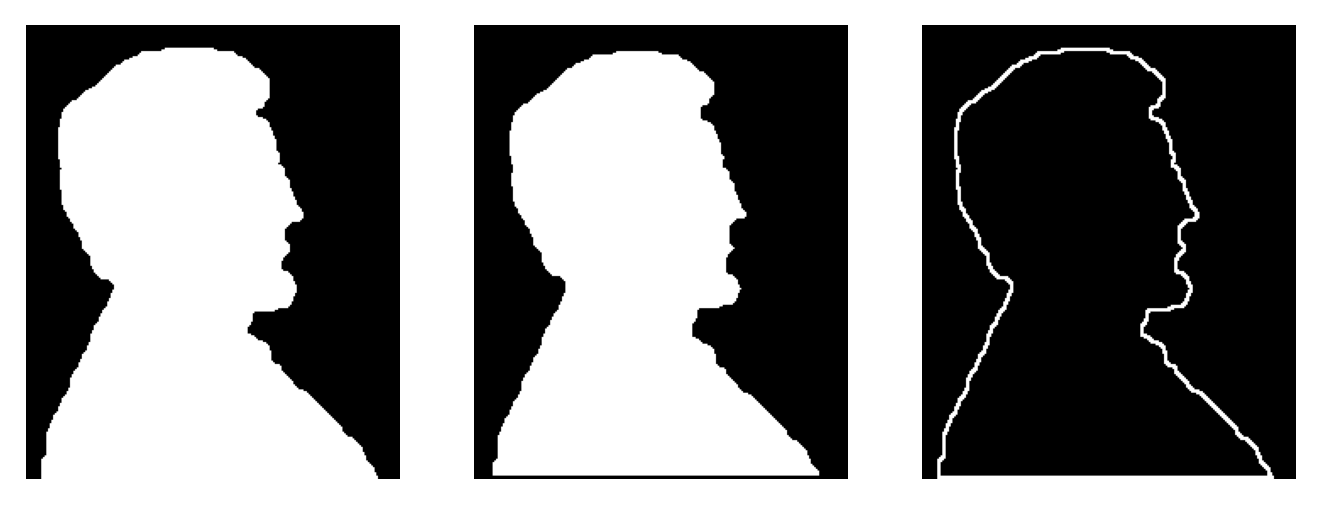

In [ ]:
g = nd.binary_erosion(f,np.ones((5,5))).astype(np.int8)
e = f - g
plt.figure(dpi=256)
plt.subplot(131)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.subplot(132)
plt.imshow(g,cmap='gray')
plt.axis('off')
plt.subplot(133)
plt.imshow(e,cmap='gray')
plt.axis('off')
plt.show()

## Connected Components

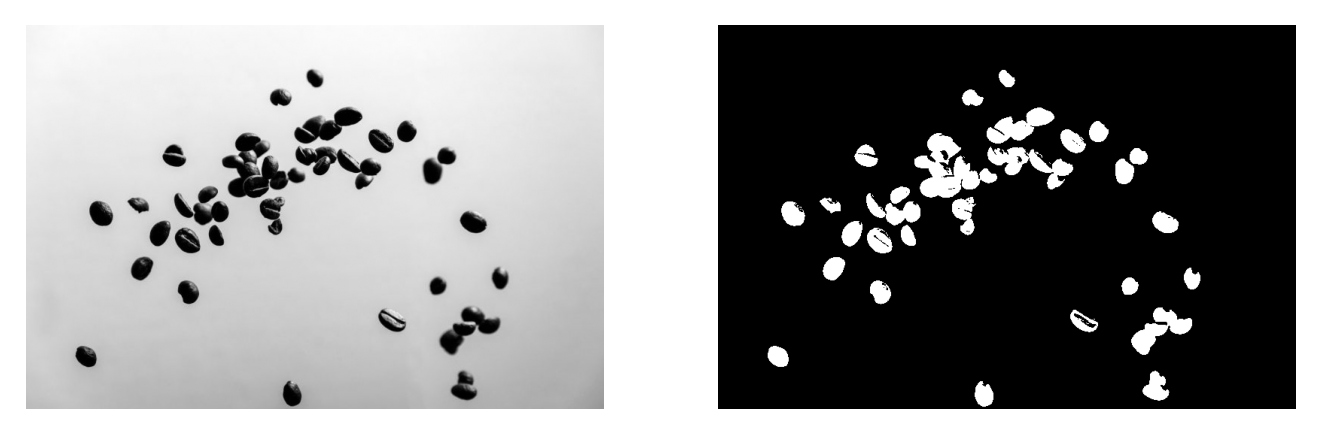

In [13]:
from PIL import Image
import numpy as np # Add this line
import matplotlib.pyplot as plt # Add this line
I = Image.open(imgpath+'/coffee bin.jpg').convert('L')
f = np.array(I)
f2 = f<128
plt.figure(dpi=256)
plt.subplot(121)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.subplot(122)
plt.imshow(f2,cmap='gray')
plt.axis('off')
plt.show()

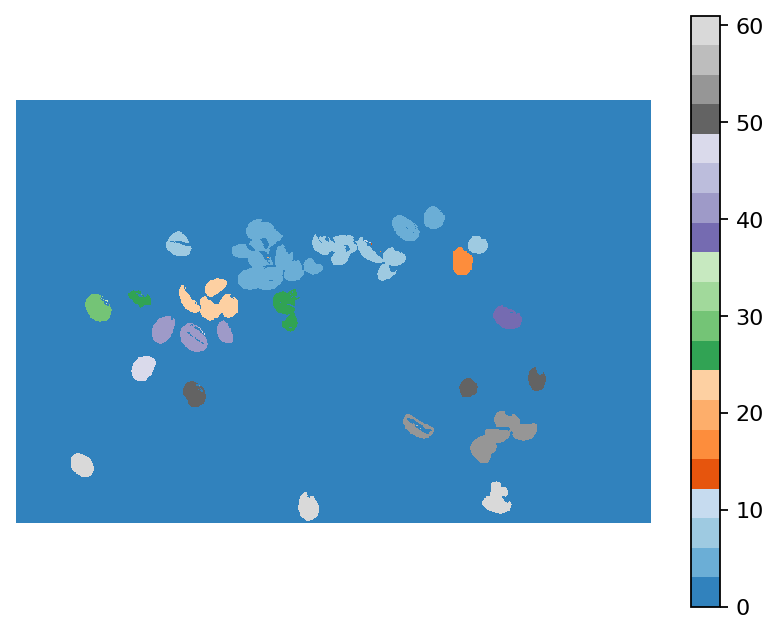

In [15]:
import scipy.ndimage as nd
l, m = nd.label(f2)
plt.figure(dpi=160)
plt.imshow(l,interpolation='nearest',cmap='tab20c')
plt.axis('off')
plt.colorbar()
plt.show()

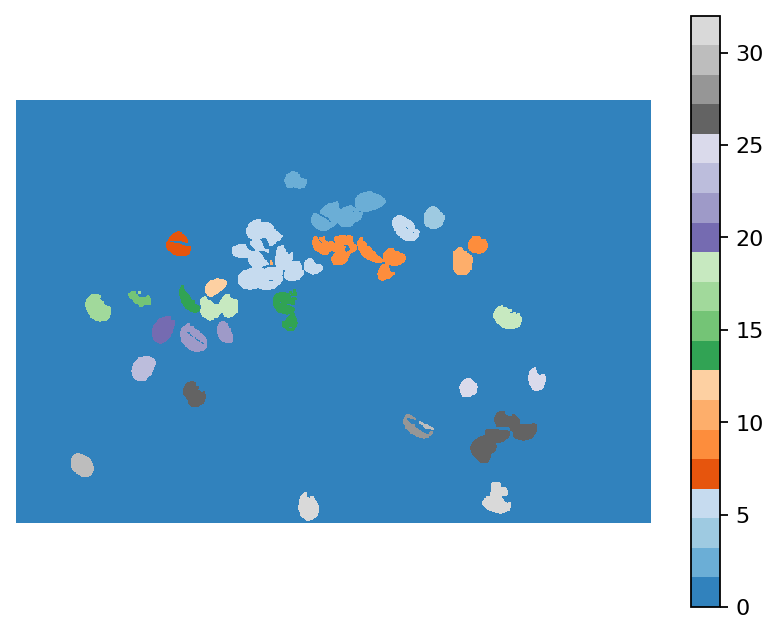

In [16]:
f3 = nd.binary_opening(f2, np.ones((3,3)))
l, m = nd.label(f3)
plt.figure(dpi=160)
plt.imshow(l,interpolation='nearest',cmap='tab20c')
plt.axis('off')
plt.colorbar()
plt.show()

In [17]:
cc = np.zeros((m-1,2))
for i in range(1,m):
  cc[i-1,0] = i
  cc[i-1,1] = np.sum(l==i)
  print(f'index: {int(cc[i-1,0])}, number of pixels: {int(cc[i-1,1])}')

index: 1, number of pixels: 337
index: 2, number of pixels: 434
index: 3, number of pixels: 2078
index: 4, number of pixels: 537
index: 5, number of pixels: 705
index: 6, number of pixels: 4247
index: 7, number of pixels: 597
index: 8, number of pixels: 2390
index: 9, number of pixels: 412
index: 10, number of pixels: 661
index: 11, number of pixels: 25
index: 12, number of pixels: 411
index: 13, number of pixels: 408
index: 14, number of pixels: 929
index: 15, number of pixels: 297
index: 16, number of pixels: 15
index: 17, number of pixels: 732
index: 18, number of pixels: 1006
index: 19, number of pixels: 710
index: 20, number of pixels: 679
index: 21, number of pixels: 399
index: 22, number of pixels: 747
index: 23, number of pixels: 683
index: 24, number of pixels: 437
index: 25, number of pixels: 402
index: 26, number of pixels: 596
index: 27, number of pixels: 2117
index: 28, number of pixels: 389
index: 29, number of pixels: 78
index: 30, number of pixels: 605
index: 31, number

In [18]:
ind_max = np.argmax(cc[:,1])
print(f'the largest component: index {int(ind_max)}, # of pixels: {int(cc[ind_max,1])}')
ind_min = np.argmin(cc[:,1])
print(f'the smallest component: index {int(ind_min)}, # of pixels: {int(cc[ind_min,1])}')

the largest component: index 5, # of pixels: 4247
the smallest component: index 15, # of pixels: 15


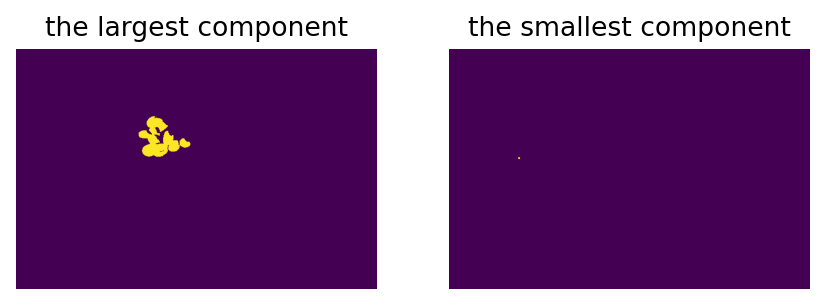

In [19]:
plt.figure(dpi=160)
plt.subplot(121)
plt.imshow(l==cc[ind_max,0])
plt.axis('off')
plt.title('the largest component')
plt.subplot(122)
plt.imshow(l==cc[ind_min,0])
plt.axis('off')
plt.title('the smallest component')
plt.show()

## Exercise
- 각자 준비한 사진을 불러와서 관심있는 대상의 숫자를 셀 수 있는 알고리즘을 morphological processing을 기반으로 구현해보자.
- 배운 내용들을 적절하게 활용하여 개수를 세는 알고리즘의 정확도를 높여보자.

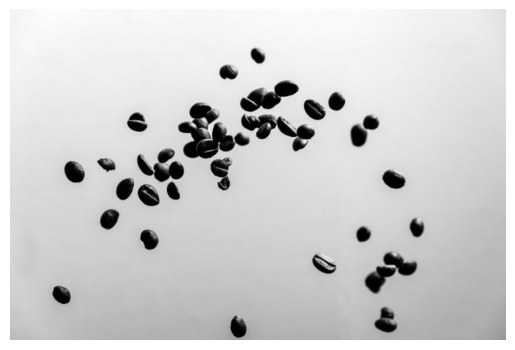

In [23]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
f = Image.open(imgpath+'/coffee bin.jpg').convert('L')
f = np.array(f)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

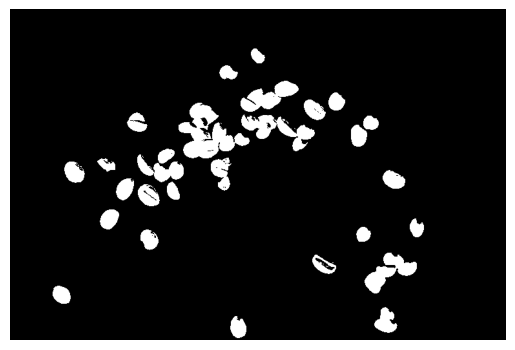

In [25]:
A = f<128
plt.imshow(A,cmap='gray')
plt.axis('off')
plt.show()

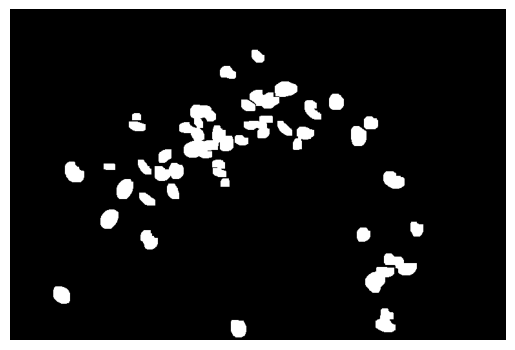

In [26]:
A_e = nd.binary_opening(A,np.ones((9,9)))
plt.imshow(A_e,cmap='gray')
plt.axis('off')
plt.show()

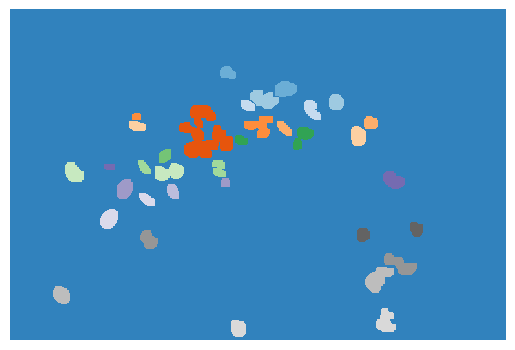

  36개가 맞나요?


In [27]:
l, m = nd.label(A_e)
plt.imshow(l,interpolation='nearest',cmap='tab20c')
plt.axis('off')
plt.show()
print(f'  {m}개가 맞나요?')